In [12]:

import os, io, time, json, hashlib, pathlib, sys
import requests
import pandas as pd
import numpy as np
import importlib
from dotenv import load_dotenv
import re
import matplotlib.pyplot as plt
import seaborn as sns

from urllib.parse import urlparse
from datetime import datetime, timedelta
import config
import functions2 as f2
import functions1 as f1
import risk_matrix
import books

# print(holdings.IBKR_live)

importlib.reload(books)
importlib.reload(f2)
importlib.reload(config)

# def build_returns_matrix_in_chf(
#     holdings: list[dict],
#     params: dict = {},
#     window_start: str = None,
#     window_end: str = None,
#     no_fx: bool = False,
#     usd_shift: bool = False,
#     DEBUG: bool = False,
# ) -> tuple[pd.DataFrame, pd.DataFrame, pd.Series]:
#     """
#     Build CHF daily returns matrix for the provided holdings.
#         holdings: list of dicts with tickers:
#       - name: row/column label in outputs
#       - ticker: EODHD tickerbol (e.g., 'SWDA.LON', 'IBM')
#       - ccy: base currency of the asset price series (GBP/USD/EUR/CHF)
#       - gbx: bool; if True, divide close by 100.0 (LSE pence)
#       - position: number of shares held (float)
#       - include_fx_vol: bool; when False, strip FX volatility (i.e., hedged in risk). When True or missing, include FX volatility.

#         Returns:
#       rets_df: DataFrame of CHF log returns, T x N
#       prices_df: DataFrame of CHF closes, T x N
#       weights: Series aligned to columns in rets_df
#     """
#     if window_end is None:
#         window_end = pd.to_datetime(datetime.now().strftime('%Y-%m-%d'))
#     else:
#         window_end = pd.to_datetime(window_end)
#     if window_start is not None:
#         window_start = pd.to_datetime(window_start)
#         if window_start >= window_end:
#             raise ValueError("window_start must be before window_end")

#     # ------------BUILD CHF CLOSE SERIES PER ASSET-------------------
#     fx_map = f2.make_fx_map(holdings, params, no_fx, usd_shift)
#     if DEBUG:
#         print(f">>>FX keys loaded: {list(fx_map.keys())}")

#     assets_close_local_df = pd.DataFrame()
#     assets_close_chf_df = pd.DataFrame()
#     for h in holdings:
#         name = h['name']
#         # print(f'>>>>>>>>>>>>>> Processing {name} >>>>>>>>')
#         ccy   = h["ccy"].upper()

#         if h.get("type", "").lower() == "cash":
#             asset_close_local_s = f2.make_cash_series(ccy, fx_map, window_start, window_end)
#         else:
#             ticker   = h.get("ticker")
#             px_df = f1.fetch_csv_robust(ticker, params=params)
#             asset_close_local_s = f1.sort_cols(px_df)
#         # print('asset close local s', asset_close_local_s.iloc[-1])    
#         assets_close_local_df[name] = asset_close_local_s
#         ccy = h.get('ccy','').upper()

#         # DEAL WITH GBX
#         gbx = bool(h.get('gbx', False))
#         if gbx and ccy != 'GBP':
#             raise ValueError(f"gbx=True only valid for GBP assets, got {name} in {ccy}")
#         series_local = asset_close_local_s / 100.0 if gbx else asset_close_local_s

#         # DECIDE IF TO REMOVE FX VOL IN RETURNS
#         include_fx_vol_bool = h.get('include_fx_vol', True)
#         if include_fx_vol_bool == False:
#             print(f"Removing FX vol for {name} ({ccy}), is this hedged?")
#         if ccy == 'CHF' or no_fx or (not include_fx_vol_bool) or h.get('type','').lower()=='cash':
#             # print(f'No FX conversion for {name} ({ccy})')
#             asset_close_chf_s = series_local.rename(name)
#         else:
#             # OTHERWISE INCLUDE FX VOL
#             # print(f'Converting {name} from {ccy} to CHF')
#             fx = fx_map.get(f"{ccy}CHF", pd.Series(dtype=float))

#             fx_aligned = fx.reindex(series_local.index).ffill()
#             # ensure last value available even if FX lags one or two days
#             if fx_aligned.iloc[-1] != fx_aligned.dropna().iloc[-1]:
#                 fx_aligned.iloc[-1] = fx_aligned.dropna().iloc[-1]
#             asset_close_chf_s = (series_local * fx_aligned).rename(name)

#             # print(f'CHF close last for {name}: {asset_close_chf_s.iloc[-1]}')
#         assets_close_chf_df[name] = asset_close_chf_s

#     hedged_cash = [
#         h['name'] for h in holdings
#         if h.get('type','').lower() == 'cash' and h.get('include_fx_vol')
#     ]
#     for n in hedged_cash:
#         if n in assets_close_chf_df.columns:
#             assets_close_chf_df[n] = 1.0


#     # ALIGN ON COMMON DATES
#     prices_df = assets_close_chf_df.dropna(how="any")   
#     if DEBUG and not prices_df.empty:
#         print(
#             f">>>Common window: {prices_df.index.min().date()} → {prices_df.index.max().date()} "
#             f"({len(prices_df)} rows before tail)"
#         )
#     # TRIM
#     prices_df = f2.trim_series(prices_df, window_start, window_end)

#     # ''''''''''''

#     # MAKE LOG RETURNS
#     rets_df = np.log(prices_df / prices_df.shift(1)).dropna()

#     if window_start or window_end:
#         window = window_end - window_start
#         # convert window to int
#         if prices_df.shape[0] < (window.days * 0.73):
#             print(
#                 f"After alignment only {prices_df.shape[0]} rows remain "
#                 f"(expected {window}). Data source may not have full history."
#             )
    
#     if rets_df.isna().any().any():
#         raise ValueError("NaNs remained in returns after shift/drop; check data alignment.")
#     if (prices_df <= 0).any().any():
#         raise ValueError("Non-positive prices encountered; check source data.")


#     # GET CHF VALUE FOR EACH HOLDING (valuation always in CHF at as-of)
#     chf_values = {}
#     asof = prices_df.index[-1]
#     for h in holdings:
#         name = h['name']
#         size = h.get('position', 0.0)
#         chf_value = f2.get_holding_value_chf(h, fx_map, assets_close_local_df, assets_close_chf_df, asof)
#         # print(f'CHF value {size} of {h["name"]}: {chf_value:.2f}')
#         if chf_value is not None:
#             chf_values[name] = chf_value
        
#     total_val = sum(chf_values.values())
#     print(f'LOOKBACK DAYS/REGIME: {window_start} to {window_end}  ({(window_end - window_start).days} days)')
#     print(f"Total portfolio value (CHF): {total_val:.2f}")

#     # CALCULATE WEIGHTS (CHF)
#     weights = pd.Series()
#     for h in holdings:
#         name = h["name"]
#         size = h.get('position', 0.0)
#         value = float(chf_values[name])
#         weight = value / total_val
#         weights[name] = weight

#         # JUST FOR THE PRINTING
#         last = assets_close_chf_df[name].iloc[-2]

#         print(f"{name}: value {value:.2f} CHF,  last: {last:.2f} * {size}")


#     if not np.isclose(weights.sum(), 1.0, atol=1e-6):
#         raise ValueError(f"Weights must sum to 1. Got {weights.sum():.6f}" "check postions input in holdings.")
#     return rets_df, prices_df, weights



# def portfolio_risk(rets_df: pd.DataFrame, weights: pd.Series) -> dict:
#     """
#     Compute annualized vols, correlation, covariance, portfolio vol,
#     marginal risk contribution (MRC), and percent risk contribution (PRC).
#     """
#     # Annualized stats
#     cov_daily = rets_df.cov()
#     cov_annual = cov_daily * 252.0
#     vol_ann = rets_df.std() * np.sqrt(252.0)
#     corr = rets_df.corr()

#     # Align weights
#     w = weights.reindex(rets_df.columns).astype(float)
#     Sigma_w = cov_annual @ w
#     port_var = float(w @ Sigma_w)
#     port_vol = float(np.sqrt(port_var)) if port_var > 0 else 0.0

#     # Contributions
#     mrc = Sigma_w / port_vol if port_vol > 0 else Sigma_w * 0.0
#     prc = (w * Sigma_w) / port_var if port_var > 0 else w * 0.0

#     summary = pd.DataFrame({
#         "Weight": w,
#         "Vol_1Y_CHF": vol_ann,
#         "MRC": mrc,           # ∂σ_p/∂w_i (absolute marginal contribution)
#         "PRC_%": prc * 100.0  # percent contribution to total variance (sums ~100%)
#     }).sort_values("PRC_%", ascending=False)

#     return {
#         "port_vol": port_vol,
#         "cov_annual": cov_annual,
#         "corr": corr,
#         "vol_ann": vol_ann,
#         "mrc": mrc,
#         "prc": prc,
#         "summary": summary,
#     }



<module 'config' from '/Users/alexwebb/laptop_coding/risk_matrix/config.py'>

------
BOOK: IBKR_live 
-------
After alignment only 104 rows remain (expected 194 days 00:00:00). Data source may not have full history.
LOOKBACK DAYS/REGIME: 2025-04-10 00:00:00 to 2025-10-21 00:00:00  (194 days)
Total portfolio value (CHF): 24884.41
VEU: value 6356.06 CHF,  last: 57.27 * 111
EMIM: value 6508.54 CHF,  last: 35.10 * 187
VUAG: value 3828.60 CHF,  last: 101.73 * 38
ISJP: value 1250.82 CHF,  last: 40.53 * 31
IEMS: value 643.93 CHF,  last: 108.30 * 6
XXSC: value 1212.48 CHF,  last: 61.32 * 20
SGLN: value 2758.17 CHF,  last: 65.79 * 42
IPLT: value 736.71 CHF,  last: 19.48 * 40
REMX: value 271.44 CHF,  last: 11.43 * 25
INRG: value 2194.53 CHF,  last: 7.76 * 290
CASH_CHF: value 8313.00 CHF,  last: 1.00 * 0.0
CASH_GBP: value -43.65 CHF,  last: 1.00 * 0.0
CASH_USD: value -7894.52 CHF,  last: 0.79 * 0.0
CASH_JPY: value -1251.70 CHF,  last: 0.01 * 0.0
Portfolio σ (annualized, CHF): 11.88%
 CORE EQUITY BAND = 15 - 30%, DIVERSIFIERS = 5 - 12%, TACTICALS <= 10%,
equity core max 30%

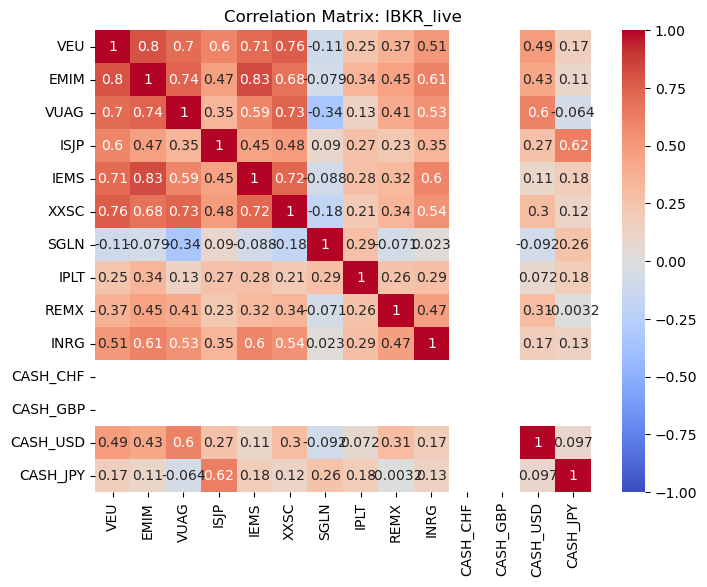

In [14]:

PORTFOLIO = 'IBKR_live' 
            # 'IBKR_live_adj'  
            # 'IBKR_sim' 
            # 'exp' 
holdings=getattr(books, PORTFOLIO)  # verify it exists

DEBUG = False
window_start = '2025-4-10'
window_end = None
print('------\nBOOK:', PORTFOLIO, '\n-------')



rets_df, prices_df, w = risk_matrix.build_returns_matrix_in_chf(holdings, params=config.params, no_fx=False, usd_shift=False, window_start=window_start, window_end=window_end,  DEBUG=DEBUG)

risk = risk_matrix.portfolio_risk(rets_df, w)

# print( rets_df.tail(3) )
print("Portfolio σ (annualized, CHF): {:.2%}".format(risk["port_vol"]))
print(" CORE EQUITY BAND = 15 - 30%, DIVERSIFIERS = 5 - 12%, TACTICALS <= 10%,")
print('equity core max 30%, diversifiers max 12%, tacticals max 10%, total max 15%')
print(risk["summary"].round({"Weight":3,"Vol_1Y_CHF":3,"MRC":3,"PRC_%":1, }))
print(f'CORRELATION:')
print(f'{risk["corr"].round(2)}')
print(f'COVARIANCE:')
print(f'{risk["cov_annual"]}')

corr_matrix = risk["corr"]

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title(f"Correlation Matrix: {PORTFOLIO}")
plt.show()

In [34]:
def eod_search(quey: str, token: str):
    import requests, pandas as pd
    url = f"https://eodhd.com/api/search/{quey}?api_token={token}&fmt=json"
    r = requests.get(url, timeout=30); r.raise_for_status()
    hits = r.json()
    # Return a small table to pick from
    return pd.DataFrame([{
        "code": h.get("Code"),
        "exchange": h.get("Exchange"),
        "name": h.get("Name"),
        "currency": h.get("Currency"),
        "type": h.get("Type"),
        "startdate": h.get("StartDate"),
        # earliet date

    } for h in hits])

# Usage:
df = eod_search("litg", config.EOD_API)
# pick the line with the longest available history (often XETRA/LSE/SIX)
print(df)

   code exchange                                               name currency  \
0  LITG      LSE  Global X Lithium & Battery Tech UCITS ETF USD ...      GBP   

  type startdate  
0  ETF      None  


In [ ]:
cc

## GET THE EARLIEST DATE ##

In [17]:
START = '2020-01-02'
ticker = 'VEU.US'


# Fetch EODHD daily FX and build a Series
fx_df = f1.fetch_csv_robust(ticker, params=config.params)
print(fx_df.tail(3))

             Open    High     Low  Close  Adjusted_close   Volume
Date                                                             
2025-10-10  71.78  71.850  70.090  70.20           70.20  3308400
2025-10-13  71.01  71.380  70.920  71.26           71.26  1659200
2025-10-14  70.62  71.545  70.515  71.27           71.27  1936194


## Equity correlation drift check
We’ll:
- compute a 60-day rolling average pairwise correlation across the equity ETFs in your `rets_df`.
- show the 1-year view you’re using now (limited by `XMWX`).
- also compute a 3-year view excluding `XMWX` (if data exist), to see whether the increase is structural or just recent.

In [ ]:
# 1) Current 1-year view (already in rets_df)
# Pick equity ETFs present in rets_df
all_cols = list(rets_df.columns)
EQUITY_LIKE = [c for c in ["EMIM","VUAG","WSML","XMWX","IBM"] if c in all_cols]

if len(EQUITY_LIKE) >= 2:
    rets_eq_1y = rets_df[EQUITY_LIKE]
    # 60D rolling average of pairwise correlation (off-diagonal mean)
    def offdiag_mean(corr_m):
        if corr_m.shape[0] < 2:
            return np.nan
        n = corr_m.shape[0]
        return (corr_m.values.sum() - n) / (n*(n-1))

    roll_avg_corr_1y = (
        rets_eq_1y.rolling(60).corr().groupby(level=0).apply(lambda c: offdiag_mean(c))
    )

    print("1Y rolling(60) avg pairwise equity corr (tail):")
    print(roll_avg_corr_1y.dropna().tail(10))
else:
    print("Not enough equity-like tickers to compute 1Y pairwise correlation.")

# 2) Longer 3Y view excluding XMWX (if data available): re-fetch or extend window is out of scope here,
# but we can approximate by checking if older data exist in prices_df; if not, we demonstrate exclusion-only.
try:
    # If you want to explicitly exclude XMWX to avoid its shorter history limiting the window
    EQUITY_NO_XMWX = [c for c in EQUITY_LIKE if c != "XMWX"]
    if len(EQUITY_NO_XMWX) >= 2:
        # Use available rets_df (1Y). For a true 3Y view, rerun 
        rets_eq_ex = rets_df[EQUITY_NO_XMWX]
        roll_avg_corr_ex = (
            rets_eq_ex.rolling(60).corr().groupby(level=0).apply(lambda c: offdiag_mean(c))
        )
        print("Ex-XMWX rolling(60) avg pairwise equity corr (tail):")
        print(roll_avg_corr_ex.dropna().tail(756))
    else:
        print("Not enough non-XMWX equity-like tickers to compute ex-XMWX correlation.")
except Exception as e:
    print("Correlation analysis note:", e)


1Y rolling(60) avg pairwise equity corr (tail):
Date
2025-09-15    0.391039
2025-09-16    0.405657
2025-09-17    0.406110
2025-09-18    0.410732
2025-09-19    0.418680
2025-09-22    0.412419
2025-09-23    0.420255
2025-09-24    0.426989
2025-09-25    0.403509
2025-09-26    0.399293
dtype: float64
Ex-XMWX rolling(60) avg pairwise equity corr (tail):
Date
2022-11-08    0.373665
2022-11-09    0.384303
2022-11-10    0.390019
2022-11-11    0.383012
2022-11-14    0.386920
                ...   
2025-09-22    0.412419
2025-09-23    0.420255
2025-09-24    0.426989
2025-09-25    0.403509
2025-09-26    0.399293
Length: 696, dtype: float64


## 3-year view excluding XMWX
We will rebuild returns with a longer lookback (756 trading days ≈ 3y) and exclude `XMWX` so the window isn’t truncated, then recompute the 60D rolling average pairwise correlation.

## USD exposure check (manual)
This cell computes a per-holding USD exposure using explicit `USD_exposure` look-through where provided (e.g., WSML≈0.58), defaults to 1.0 for USD-priced assets not marked `include_fx_vol=False` (i.e., unhedged in risk), and includes `CASH_USD` as a negative hedge. Values are in CHF; a hedge recommendation in USD is derived from the `CASH_USD` series (USDCHF).

## Period-based volatility view (e.g., last 6 months)
Use this section to compute volatility and risk contributions over a specific recent window, and compare with the immediately prior, equal-length window. Set `MONTHS` (default 6). If your `rets_df` covers more than this window, the slice will use calendar months based on the latest date in `rets_df`.

In [6]:
# Parameters
MONTHS = 6  # set to any integer number of months for the analysis window
RECENT_START = None  # Optional explicit start date string like "2025-03-01" (your liberation day). If set, overrides MONTHS.
ANNUALIZATION = 252.0
if MONTHS is not None and (not isinstance(MONTHS, int) or MONTHS <= 0):
    raise ValueError("MONTHS must be a positive integer when used.")

# Determine date boundaries
latest = rets_df.index.max()
first = rets_df.index.min()
if pd.isna(latest):
    raise ValueError("rets_df is empty or has invalid index.")

if RECENT_START:
    # Use explicit recent start date (e.g., liberation day)
    recent_start = pd.Timestamp(RECENT_START)
    if recent_start > latest:
        raise ValueError(f"RECENT_START {recent_start.date()} is after latest return date {latest.date()}.")
    recent_start = max(recent_start.normalize(), first)
    # Make prior window equal length in time
    window_len = latest.normalize() - recent_start
    prior_end = recent_start
    prior_start = max((prior_end - window_len).normalize(), first)
else:
    # Use calendar-month-based window
    recent_start = (latest - pd.DateOffset(months=MONTHS)).normalize()
    prior_start  = (latest - pd.DateOffset(months=2*MONTHS)).normalize()
    recent_start = max(recent_start, first)
    prior_start  = max(prior_start, first)
    prior_end    = recent_start

# Build slices: recent window and prior equal-length window
rets_recent = rets_df.loc[rets_df.index >= recent_start]
rets_prior  = rets_df.loc[(rets_df.index >= prior_start) & (rets_df.index < recent_start)]

def describe_period(df: pd.DataFrame, label: str):
    if df.empty or df.shape[0] < 20:
        print(f"[{label}] Window too short: {df.shape[0]} rows. Skipping.")
        return None
    # Reuse portfolio_risk with the existing weights w (valued at the global as-of).
    res = portfolio_risk(df, w)
    print(f"[{label}] rows={df.shape[0]}, from {df.index.min().date()} to {df.index.max().date()}")
    print(f"[{label}] Portfolio σ (annualized, CHF): {res['port_vol']:.2%}")
    # Show top contributors
    print(res["summary"].round({"Weight":3,"Vol_1Y_CHF":3,"MRC":3,"PRC_%":1}).head(15))
    return res

res_recent = describe_period(rets_recent, f"Recent {MONTHS}M" if not RECENT_START else f"Recent since {pd.Timestamp(RECENT_START).date()}")
res_prior  = describe_period(rets_prior,  f"Prior window")

# Compare if both exist
if (res_recent is not None) and (res_prior is not None):
    # Asset vol deltas (annualized)
    vol_recent = res_recent["summary"]["Vol_1Y_CHF"]
    vol_prior  = res_prior["summary"]["Vol_1Y_CHF"].reindex(vol_recent.index)
    vol_delta  = (vol_recent - vol_prior).dropna().sort_values(ascending=False)
    print("\nChange in asset vols (annualized, CHF): top movers")
    print(vol_delta.round(3).head(15))

    # Percent risk contribution deltas
    prc_recent = res_recent["summary"]["PRC_%"]
    prc_prior  = res_prior["summary"]["PRC_%"].reindex(prc_recent.index)
    prc_delta  = (prc_recent - prc_prior).dropna().sort_values(ascending=False)
    print("\nChange in PRC (percentage points): top movers")
    print(prc_delta.round(2).head(15))

    # Portfolio vol delta
    port_vol_delta = res_recent["port_vol"] - res_prior["port_vol"]
    print(f"\nChange in portfolio σ (annualized, CHF): {port_vol_delta:+.2%}")

[Recent 6M] rows=121, from 2025-03-26 to 2025-09-26
[Recent 6M] Portfolio σ (annualized, CHF): 9.58%
          Weight  Vol_1Y_CHF    MRC  PRC_%
EMIM       0.191       0.190  0.173   34.6
VEU        0.108       0.223  0.168   18.8
WSML       0.094       0.206  0.178   17.6
VUAG       0.080       0.215  0.175   14.5
IBM        0.057       0.335  0.197   11.8
HEAL       0.043       0.231  0.163    7.3
YCA        0.031       0.403  0.215    7.0
SGLN       0.069       0.193  0.046    3.3
CASH_CHF   0.263       0.000  0.000    0.0
ERNS       0.272       0.008 -0.000   -0.1
CASH_USD  -0.080       0.113  0.043   -3.6
CASH_GBP  -0.084       0.090  0.059   -5.2
SIKA      -0.044       0.266  0.131   -6.0
[Prior window] rows=119, from 2024-09-26 to 2025-03-25
[Prior window] Portfolio σ (annualized, CHF): 7.06%
          Weight  Vol_1Y_CHF    MRC  PRC_%
EMIM       0.191       0.147  0.122   33.1
WSML       0.094       0.179  0.135   18.0
VEU        0.108       0.127  0.097   14.7
IBM        0.057  